<a href="https://colab.research.google.com/github/EverHernandez01/Teoria_de_se-ales/blob/main/Calibracion_espectral/Calibracion_sensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded_new = files.upload()

Saving resumen_potencia_error1.csv to resumen_potencia_error1.csv
Saving resumen_potencia_error7.csv to resumen_potencia_error7.csv


In [7]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/EverHernandez01/Teoria_de_se-ales/main/Calibracion_espectral/"

df1 = pd.read_csv(base_url + "resumen_potencia_error1.csv", encoding="latin1")
df7 = pd.read_csv(base_url + "resumen_potencia_error7.csv", encoding="latin1")

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("resumen_potencia_error1.csv", encoding="latin1")
df7 = pd.read_csv("resumen_potencia_error7.csv", encoding="latin7")

In [9]:
df1.head()

,Frecuencia_central_Hz,Potencia_dBm,Error_dB
0,100000000.0,-32.783880,-7.783880
1,200000000.0,-29.079094,-4.079094
2,300000000.0,-29.577310,-4.577310
3,400000000.0,-30.238398,-5.238398
4,500000000.0,-31.011883,-6.011883


In [10]:
df7.head()

,Frecuencia_central_Hz,Potencia_dBm,Error_dB
0,100000000.0,-25.490551,-0.490551
1,200000000.0,-24.047290,0.952710
2,300000000.0,-24.621360,0.378640
3,400000000.0,-25.106846,-0.106846
4,500000000.0,-25.094519,-0.094519


In [11]:
#Convierte la columna Frecuencia_central_Hz a valores numéricos.

df1["Frecuencia_central_Hz"] = pd.to_numeric(df1["Frecuencia_central_Hz"], errors="coerce")
df1["Potencia_dBm"] = pd.to_numeric(df1["Potencia_dBm"], errors="coerce")

df7["Frecuencia_central_Hz"] = pd.to_numeric(df7["Frecuencia_central_Hz"], errors="coerce")
df7["Potencia_dBm"] = pd.to_numeric(df7["Potencia_dBm"], errors="coerce")

df1 = df1.dropna()
df7 = df7.dropna()

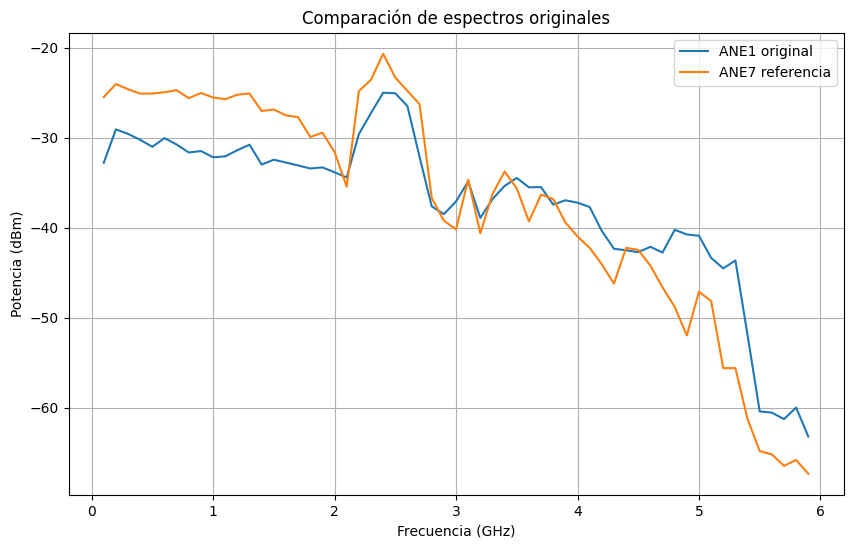

In [12]:
plt.figure(figsize=(10,6))

freq = df1["Frecuencia_central_Hz"] / 1e9  # convertir a GHz

plt.plot(freq, df1["Potencia_dBm"], label="ANE1 original")
plt.plot(freq, df7["Potencia_dBm"], label="ANE7 referencia")

plt.xlabel("Frecuencia (GHz)")
plt.ylabel("Potencia (dBm)")
plt.title("Comparación de espectros originales")

plt.legend()
plt.grid(True)

plt.show()


## Explicación del proceso de calibración espectral

El objetivo de este procedimiento es **calibrar el espectro de potencia de un nodo de medición** utilizando como referencia un nodo confiable (`Node7-Bogota`). Debido a que cada sensor puede tener errores de medición, es necesario ajustar sus valores para que coincidan con la referencia.

Primero se calcula la **función de corrección** entre el nodo que queremos calibrar y el nodo de referencia. Esta corrección depende de la frecuencia y se define como:

$$
H(f) = P_{ref}(f) - P_{node}(f)
$$

donde:

- $$P_{ref}(f)$$ es la potencia medida por el nodo de referencia.
- $$P_{node}(f)$$ es la potencia medida por el nodo que se desea calibrar.
- $$H(f)$$ representa el **error o diferencia entre ambos espectros** para cada frecuencia.

Esta función indica **cuánto debemos corregir la medición del nodo** para que coincida con la referencia.

Una vez obtenida la función de corrección, se aplica al espectro del nodo para obtener el espectro calibrado:

$$
P_{cal}(f) = P_{node}(f) + H(f)
$$

donde:

- $$P_{cal}(f)$$ es el espectro de potencia **calibrado**.

Al aplicar esta corrección, el espectro del nodo ajustado debería **aproximarse al espectro del nodo de referencia**, reduciendo así el error de medición.

Este procedimiento permite **alinear las mediciones de diferentes sensores**, garantizando que todos los nodos reporten valores consistentes en el análisis espectral.

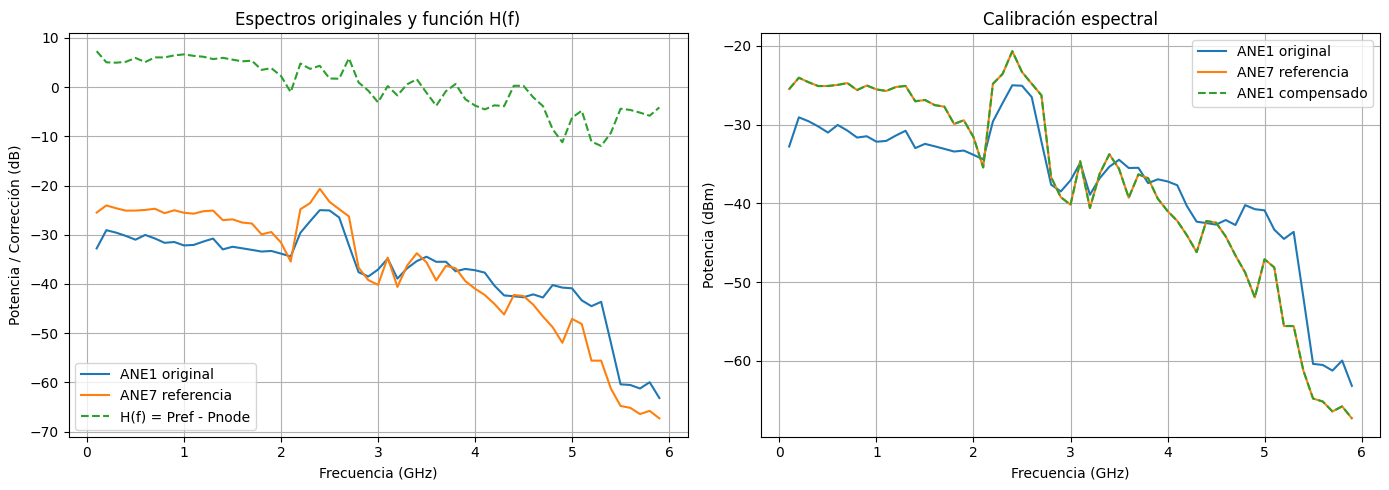

In [14]:

# cargar archivos
df1 = pd.read_csv("resumen_potencia_error1.csv", encoding="latin1")
df7 = pd.read_csv("resumen_potencia_error7.csv", encoding="latin1")

# convertir columnas a números
df1["Frecuencia_central_Hz"] = pd.to_numeric(df1["Frecuencia_central_Hz"], errors="coerce")
df1["Potencia_dBm"] = pd.to_numeric(df1["Potencia_dBm"], errors="coerce")

df7["Frecuencia_central_Hz"] = pd.to_numeric(df7["Frecuencia_central_Hz"], errors="coerce")
df7["Potencia_dBm"] = pd.to_numeric(df7["Potencia_dBm"], errors="coerce")

df1 = df1.dropna()
df7 = df7.dropna()

# calcular funciones
H = df7["Potencia_dBm"] - df1["Potencia_dBm"]
Pcal = df1["Potencia_dBm"] + H

freq = df1["Frecuencia_central_Hz"] / 1e9


# crear matriz de graficas (2 filas, 1 columna)
fig, axs = plt.subplots(1, 2, figsize=(14,5))


# ======================
# GRAFICA 1
# ======================
axs[0].plot(freq, df1["Potencia_dBm"], label="ANE1 original")
axs[0].plot(freq, df7["Potencia_dBm"], label="ANE7 referencia")
axs[0].plot(freq, H, "--", label="H(f) = Pref - Pnode")

axs[0].set_xlabel("Frecuencia (GHz)")
axs[0].set_ylabel("Potencia / Corrección (dB)")
axs[0].set_title("Espectros originales y función H(f)")
axs[0].legend()
axs[0].grid(True)


# ======================
# GRAFICA 2
# ======================
axs[1].plot(freq, df1["Potencia_dBm"], label="ANE1 original")
axs[1].plot(freq, df7["Potencia_dBm"], label="ANE7 referencia")
axs[1].plot(freq, Pcal, "--", label="ANE1 compensado")

axs[1].set_xlabel("Frecuencia (GHz)")
axs[1].set_ylabel("Potencia (dBm)")
axs[1].set_title("Calibración espectral")
axs[1].legend()
axs[1].grid(True)


plt.tight_layout()
plt.show()

## Interpretación de las gráficas

### Gráfica 1: Espectros originales y función de corrección

En esta gráfica se muestran tres curvas:

- **ANE1 original**: corresponde al espectro de potencia medido por el nodo que se desea calibrar.
- **ANE7 referencia**: corresponde al espectro de potencia medido por el nodo de referencia (`Node7-Bogota`), el cual se considera más confiable.
- **Función de corrección**: representa la diferencia entre ambos espectros para cada frecuencia.

La función de corrección se calcula como:

$$
H(f) = P_{ref}(f) - P_{node}(f)
$$

donde:

- $$P_{ref}(f)$$ es la potencia del nodo de referencia.
- $$P_{node}(f)$$ es la potencia del nodo que se desea calibrar.

Esta curva muestra **cuánto error tiene el nodo en cada frecuencia**. Si el valor es positivo, significa que el nodo mide menos potencia que la referencia; si es negativo, mide más potencia.

Por lo tanto, esta gráfica permite **visualizar la diferencia espectral entre ambos nodos** y obtener la corrección necesaria para calibrar el sensor.

---

### Gráfica 2: Aplicación de la calibración

En esta gráfica se muestran:

- **ANE1 original**: espectro del nodo antes de la calibración.
- **ANE7 referencia**: espectro del nodo de referencia.
- **ANE1 compensado**: espectro del nodo después de aplicar la corrección.

La calibración se obtiene aplicando la función de corrección al espectro original:

$$
P_{cal}(f) = P_{node}(f) + H(f)
$$

donde:

- $$P_{cal}(f)$$ es el espectro calibrado.

Después de aplicar esta corrección, el espectro compensado debería **aproximarse al espectro del nodo de referencia**. Esto indica que el error del sensor ha sido corregido.

Esta gráfica demuestra que el procedimiento de calibración **alinea las mediciones del nodo con la referencia**, reduciendo las diferencias entre ambos espectros.